In [1]:
import numpy as np
import pandas as pan
import matplotlib.pyplot as plt
import seaborn as srn

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
data = pan.read_csv(url)

# WEEK 1

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.shape

(891, 12)

In [5]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
# duplicates check

print(data.duplicated().sum())

0


In [9]:
# extract title from name

data['Title'] = data['Name'].str.extract(r',\s*([^\.]+)\.')
print(data['Title'].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64


In [10]:
# impute age using median by title + pclass

data['Age'] = data.groupby(['Title','Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
data['Age'].isnull().sum()

np.int64(0)

In [11]:
# cabin -> binary feature

data['Has_Cabin'] = data['Cabin'].notnull().astype(int)
data.drop(columns=['Cabin'],inplace=True)

In [12]:
# embarked fill with mode

data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Title          0
Has_Cabin      0
dtype: int64

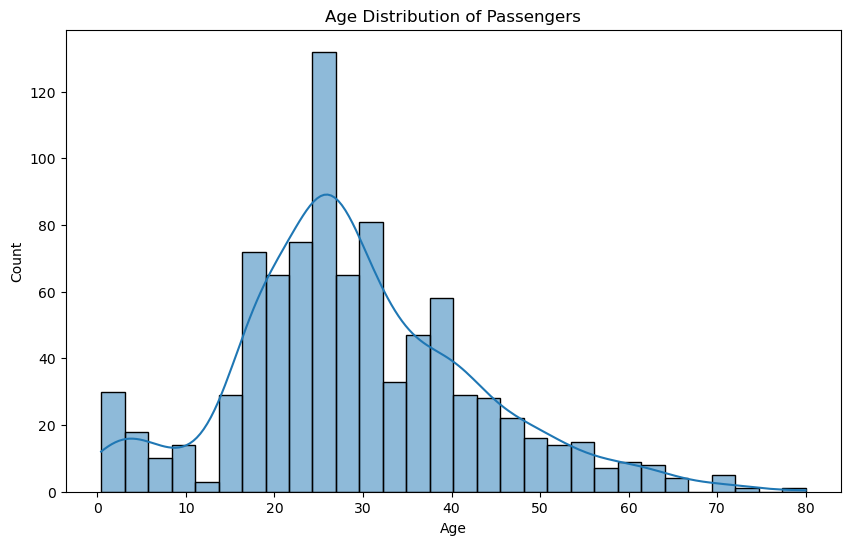

In [13]:
plt.figure(figsize=(10,6))
srn.histplot(data['Age'],bins=30,kde=True)
plt.title('Age Distribution of Passengers')
# plt.savefig('Age Distribution of Passengers.png',dpi=150,bbox_inches='tight')
plt.show()

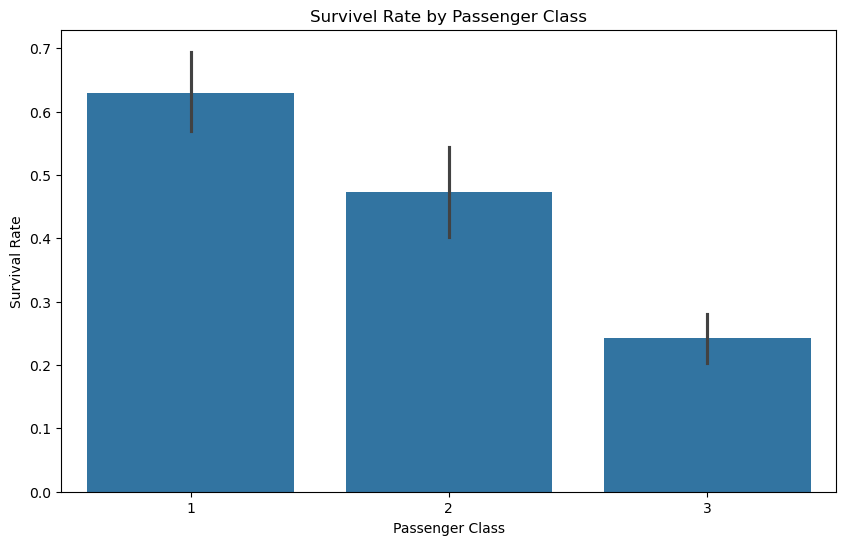

In [14]:
plt.figure(figsize=(10,6))
srn.barplot(x='Pclass',y='Survived',data=data)
plt.title('Survivel Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')
# plt.savefig('Survivel Rate by Passenger Class.png',dpi=150,bbox_inches='tight')
plt.show()

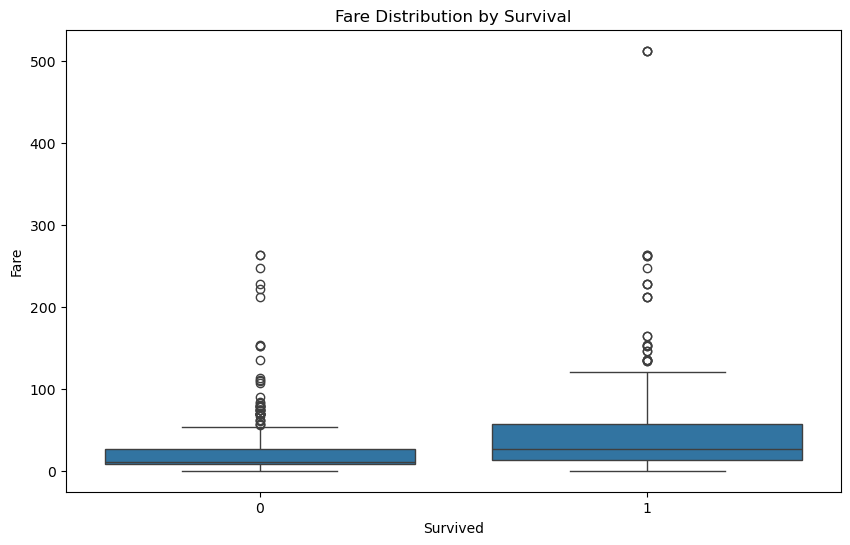

In [15]:
plt.figure(figsize=(10,6))
srn.boxplot(x='Survived',y='Fare',data=data)
plt.title('Fare Distribution by Survival')
# plt.savefig('Fare Distribution by SUrvival.png',dpi=150,bbox_inches='tight')
plt.show()

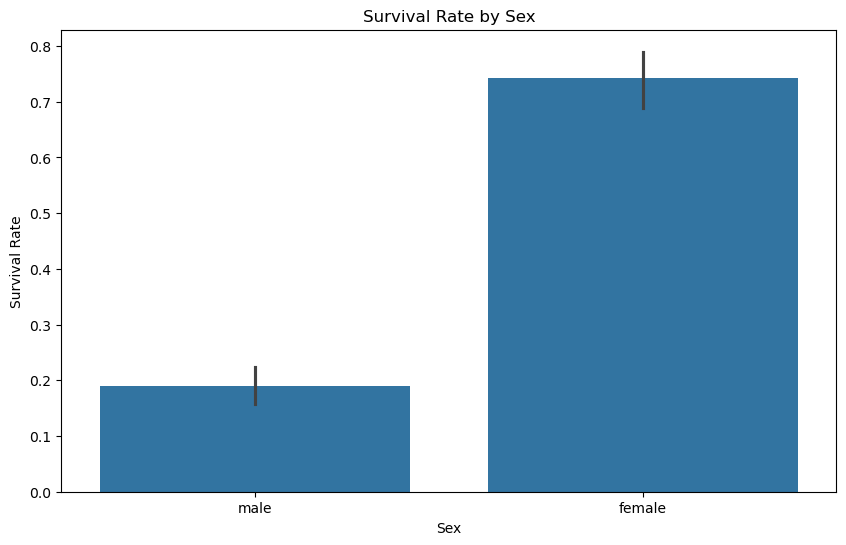

In [16]:
plt.figure(figsize=(10,6))
srn.barplot(x='Sex',y='Survived',data=data)
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
# plt.savefig('Survivel Rate by Sex.png',dpi=150,bbox_inches='tight')
plt.show()

In [17]:
data.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

# WEEK 2

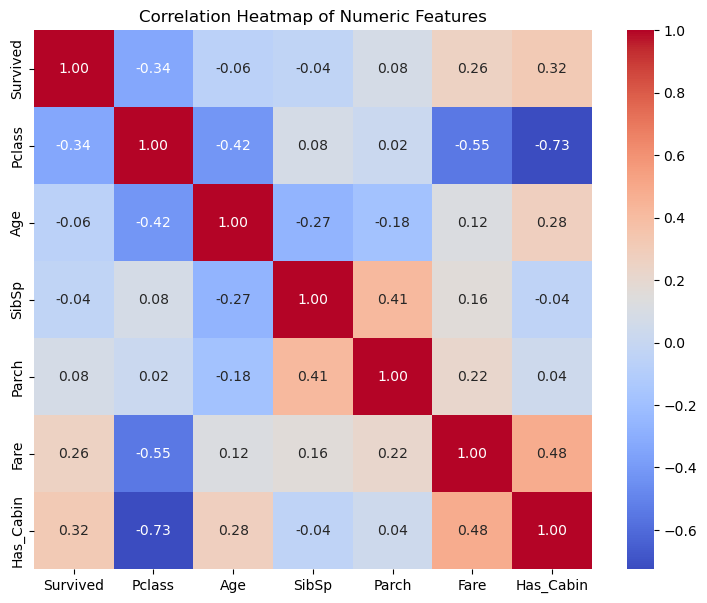

In [18]:
plt.figure(figsize=(9,7))
corr = data[['Survived','Pclass','Age','SibSp','Parch','Fare','Has_Cabin']].corr()
srn.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
# plt.savefig('Correlation_Heatmap.png',dpi=150,bbox_inches='tight')
plt.show()

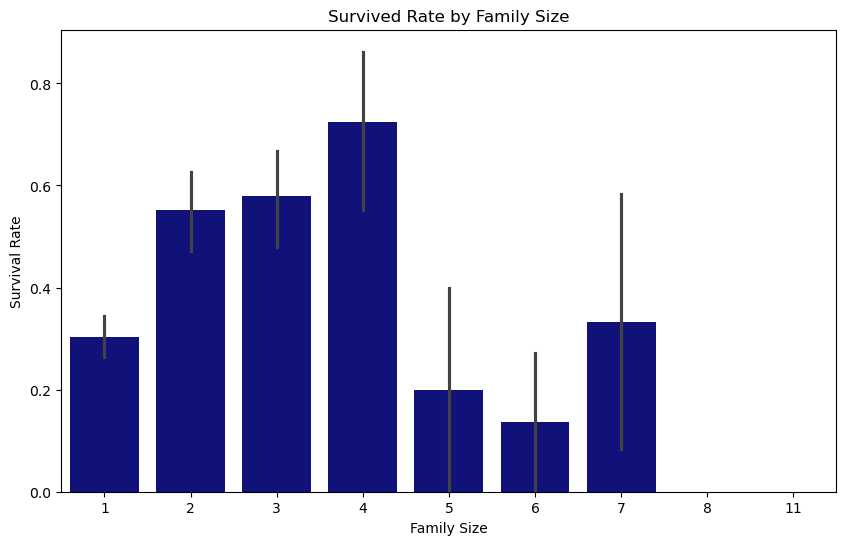

,mean,count
FamilySize,,
1,0.303538,537
2,0.552795,161
3,0.578431,102
4,0.724138,29
5,0.200000,15
6,0.136364,22
7,0.333333,12
8,0.000000,6
11,0.000000,7


In [19]:
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

plt.figure(figsize=(10,6))
srn.barplot(x='FamilySize',y='Survived',data=data,color='darkblue')
plt.title('Survived Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
# plt.savefig('Survival_by_FamilySize.png',dpi=150,bbox_inches='tight')
plt.show()
data.groupby('FamilySize')['Survived'].agg(['mean','count'])

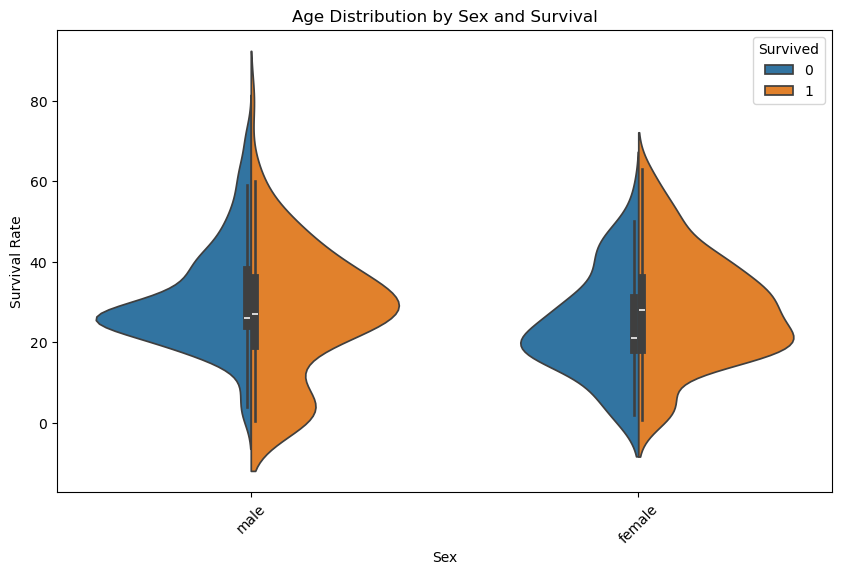

In [20]:
plt.figure(figsize=(10,6))
srn.violinplot(x='Sex',y='Age',hue='Survived',data=data,split=True)
plt.title('Age Distribution by Sex and Survival')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)
# plt.savefig('Age_Sex_Violin.png',dpi=150,bbox_inches='tight')
plt.show()

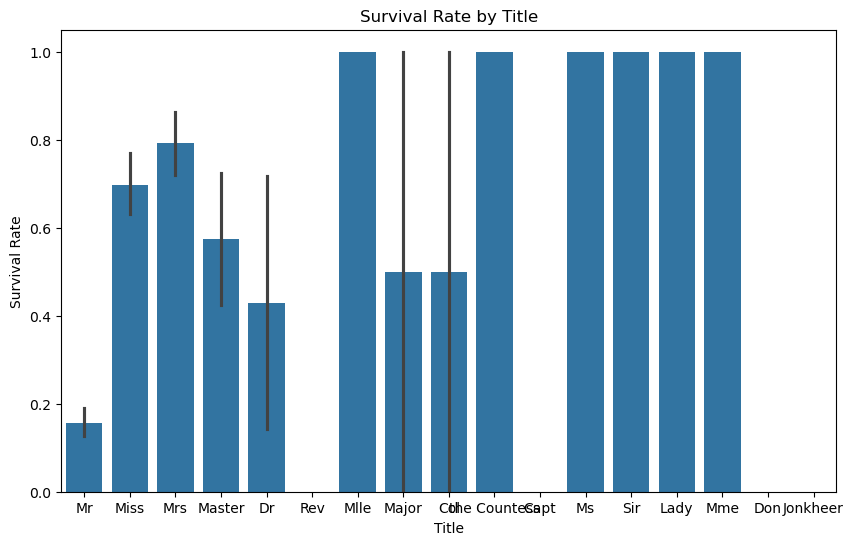

In [21]:
plt.figure(figsize=(10,6))
srn.barplot(x='Title',y='Survived',data=data,order=data['Title'].value_counts().index)
plt.title('Survival Rate by Title')
plt.ylabel('Survival Rate')
# plt.savefig('Survival_by_Title.png',dpi=150,bbox_inches='tight')
plt.show()

In [22]:
data.groupby('Title')['Survived'].mean().sort_values(ascending=False)

Title
the Countess    1.000000
Mlle            1.000000
Sir             1.000000
Ms              1.000000
Lady            1.000000
Mme             1.000000
Mrs             0.792000
Miss            0.697802
Master          0.575000
Col             0.500000
Major           0.500000
Dr              0.428571
Mr              0.156673
Jonkheer        0.000000
Rev             0.000000
Don             0.000000
Capt            0.000000
Name: Survived, dtype: float64

In [23]:
data['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

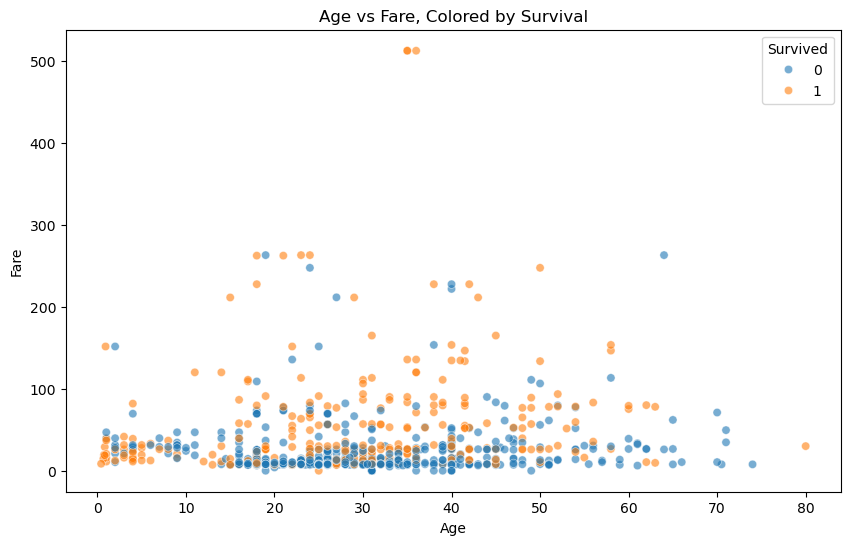

In [24]:
plt.figure(figsize=(10,6))
srn.scatterplot(x='Age',y='Fare',hue='Survived',data=data,alpha=0.6)
plt.title('Age vs Fare, Colored by Survival')
# plt.savefig('Age_vs_Fare_Survival.png',dpi=150,bbox_inches='tight')
plt.show()

# WEEK 3

In [25]:
# chi-square test
from scipy import stats

contingency = pan.crosstab(data['Sex'],data['Survived'])
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f'Chi2 statistic :- {chi2:.4f}')
print(f'p-value :- {p_value}')
print(f'Degrees of freedom :- {dof}')

Survived    0    1
Sex               
female     81  233
male      468  109
Chi2 statistic :- 260.7170
p-value :- 1.1973570627755645e-58
Degrees of freedom :- 1


In [26]:
survived_fare = data[data['Survived'] == 1]['Fare']
died_fare = data[data['Survived'] == 0]['Fare']

t_stat, p_value_fare = stats.ttest_ind(survived_fare, died_fare,equal_var=False)
print(f'T-statistic :- {t_stat:.4f}')
print(f'p-value :- {p_value_fare}')

print(f'Mean fare (survived) :- {survived_fare.mean():.2f}')
print(f'Mean fare (died) :- {died_fare.mean():.2f}')

T-statistic :- 6.8391
p-value :- 2.6993323503141236e-11
Mean fare (survived) :- 48.40
Mean fare (died) :- 22.12


In [27]:
class1_age = data[data['Pclass'] == 1]['Age']
class2_age = data[data['Pclass'] == 2]['Age']
class3_age = data[data['Pclass'] == 3]['Age']

f_stat, p_value_age = stats.f_oneway(class1_age, class2_age, class3_age)
print(f'F-statistic :- {f_stat:.4f}')
print(f'p-value :- {p_value_age}')

print(f'Mean Age (1st class) :- {class1_age.mean():.2f}')
print(f'Mean Age (2nd class) :- {class2_age.mean():.2f}')
print(f'Mean Age (3rd class) :- {class3_age.mean():.2f}')

F-statistic :- 94.8249
p-value :- 4.734514936756642e-38
Mean Age (1st class) :- 38.52
Mean Age (2nd class) :- 29.87
Mean Age (3rd class) :- 24.75


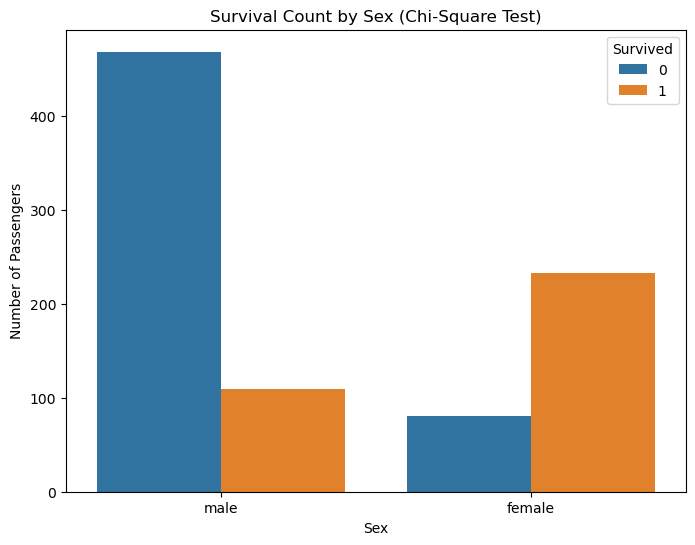

In [28]:
plt.figure(figsize=(8,6))
srn.countplot(x='Sex',hue='Survived',data=data)
plt.title('Survival Count by Sex (Chi-Square Test)')
plt.ylabel('Number of Passengers')
# plt.savefig('Chisquare_Sex_SUrvival.png',dpi=150,bbox_inches='tight')
plt.show()

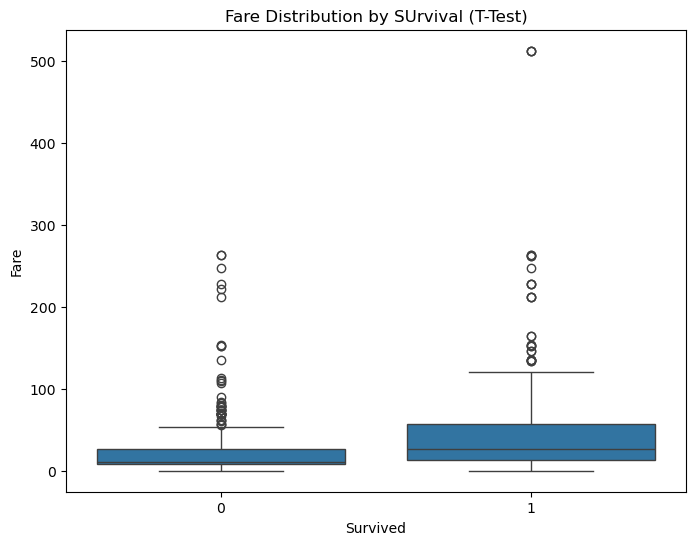

In [29]:
plt.figure(figsize=(8,6))
srn.boxplot(x='Survived',y='Fare',data=data)
plt.title('Fare Distribution by SUrvival (T-Test)')
plt.ylabel('Fare')
# plt.savefig('Ttest_Fare_Survival.png',dpi=150,bbox_inches='tight')
plt.show()

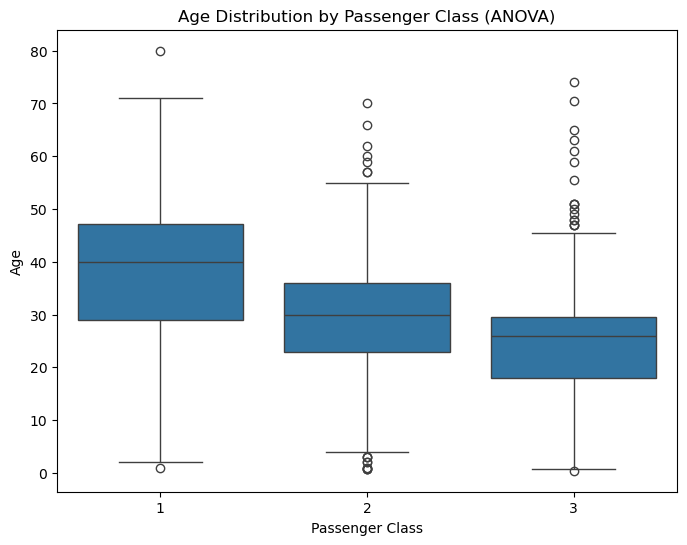

In [30]:
plt.figure(figsize=(8,6))
srn.boxplot(x='Pclass',y='Age',data=data)
plt.title('Age Distribution by Passenger Class (ANOVA)')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
# plt.savefig('Anova_Age_Class.png',dpi=150,bbox_inches='tight')
plt.show()

# WEEK 4

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [32]:
model_data = data.copy()

In [33]:
le_sex = LabelEncoder()
model_data['Sex'] = le_sex.fit_transform(model_data['Sex'])

In [34]:
le_embarked = LabelEncoder()
model_data['Embarked'] = le_embarked.fit_transform(model_data['Embarked'])

In [35]:
le_title = LabelEncoder()
model_data['Title'] = le_title.fit_transform(model_data['Title'])

In [36]:
features = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked','Has_Cabin','Title','FamilySize']

x = model_data[features]
y = model_data['Survived']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

print(x_train.shape, x_test.shape)

(712, 10) (179, 10)


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

log_model = LogisticRegression(max_iter=1000, random_state=50)
log_model.fit(x_train, y_train)

tree_model = DecisionTreeClassifier(max_depth=5, random_state=50)
tree_model.fit(x_train, y_train)

print('Models Trained')

Models Trained


In [38]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#prediction
log_pre = log_model.predict(x_test)
tree_pre = tree_model.predict(x_test)

print('--- Accuracy ---')
print('Logistic Regression Accuracy :- ',accuracy_score(y_test,log_pre))
print('Decision Tree Accuracy :- ',accuracy_score(y_test,tree_pre))

print('\n\n--- Classification Report ---')
print('\nLogistic Regression Report :- ')
print(classification_report(y_test,log_pre))

print('\nDecision Tree Report :- ')
print(classification_report(y_test,tree_pre))

--- Accuracy ---
Logistic Regression Accuracy :-  0.8212290502793296
Decision Tree Accuracy :-  0.7988826815642458


--- Classification Report ---

Logistic Regression Report :- 
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179


Decision Tree Report :- 
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.83      0.65      0.73        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.78       179
weighted avg       0.80      0.80      0.79       179



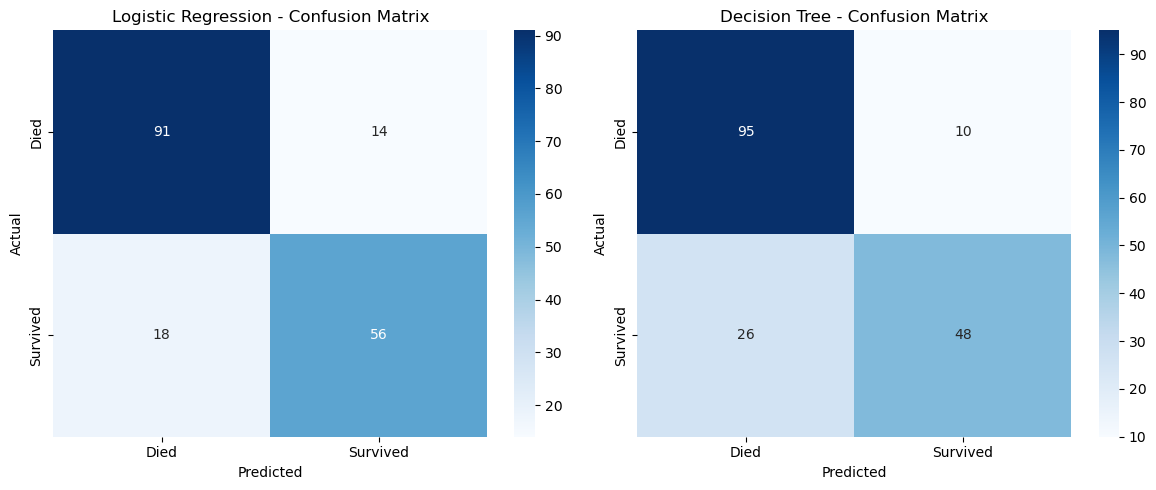

In [41]:
# confusion matrices

fig,axes = plt.subplots(1,2,figsize=(12,5))

srn.heatmap(confusion_matrix(y_test, log_pre),annot=True,fmt='d',
           ax=axes[0],cmap='Blues',
           xticklabels=['Died','Survived'],yticklabels=['Died','Survived'])

axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

srn.heatmap(confusion_matrix(y_test,tree_pre),annot=True,fmt='d',
           ax=axes[1],cmap='Blues',
           xticklabels=['Died','Survived'],yticklabels=['Died','Survived'])
axes[1].set_title('Decision Tree - Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('Confusion_Matrig.png',dpi=150, bbox_inches='tight')
plt.show()

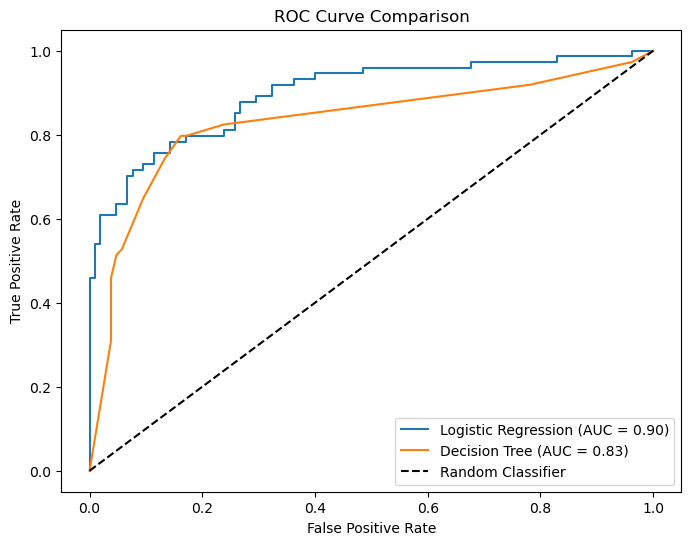

Logistic Regression AUC: 0.8968
Decision Tree AUC: 0.8300


In [42]:
from sklearn.metrics import roc_curve, roc_auc_score

log_probs = log_model.predict_proba(x_test)[:,1]
tree_probs = tree_model.predict_proba(x_test)[:,1]

log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
tree_fpr, tree_tpr, _ = roc_curve(y_test, tree_probs)

log_auc = roc_auc_score(y_test, log_probs)
tree_auc = roc_auc_score(y_test, tree_probs)

plt.figure(figsize=(8,6))
plt.plot(log_fpr, log_tpr, label=f'Logistic Regression (AUC = {log_auc:.2f})')
plt.plot(tree_fpr, tree_tpr, label=f'Decision Tree (AUC = {tree_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.savefig('ROC_Curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Logistic Regression AUC: {log_auc:.4f}")
print(f"Decision Tree AUC: {tree_auc:.4f}")